## 05 — artificial neural network classifier 

This notebook trains an Artificial Neural Network (ANN) to predict the match outcome, where the target is whether Player 1 wins.

The model uses the pre-match features created in the previous preprocessing steps. Numerical features are standardised, while categorical variables are one-hot encoded. Model configurations are compared using temporal cross-validation before the final ANN is trained and evaluated on the 2023 validation set.

The network contains: 

Input layer → Hidden layer or layers → Output

Each hidden neuron calculates a weighted combination of its inputs, adds a bias and applies an activation function. During training, the weights are repeatedly adjusted to reduce classification error.

The ANN produces a probability between 0 and 1:
- values ≥ 0.5 are classified as a Player 1 win;
- values < 0.5 are classified as a Player 2 win.

In [1]:
from pathlib import Path 
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np 
import pandas as pd 
import tensorflow as tf
import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input, optimizers

from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)
from src.temporal_cv import create_temporal_folds, validation_years
from src.evaluation import evaluate_model


In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# we load the feature dataset created in the previous notebook and reorder it
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = PROCESSED_DATA_DIR / "feature_split_matches.csv"

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [4]:
# create copies of the predefined splits
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

# check the time range of each split
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [5]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


### Feature set

The same numerical and categorical feature definitions from preprocessing.py are used. This ensures that all prediction models use exactly the same starting feature set.

In [6]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw features: 35


In [7]:
# create temporal cross-validation folds for the training set
temporal_folds= create_temporal_folds(
    train_data,
    validation_years = validation_years
)

print(
    "Number of temporal folds created:", 
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds created: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [8]:
# Fit the preprocessing steps using the training data only
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

# Apply the fitted preprocessing to training and validation data
X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# Target:
# 1 = Player 1 wins, 0 = Player 2 wins
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


After preprocessing we expect:
- 30 numerical features
- 20 one-hot encoded categorical features

With a total of 50 final model features

In [9]:
print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validating X:", X_validation.shape)
print("Validating y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print("ANN preprocessing check passed.")

Training X: (18810, 50)
Training y: (18810,)
Validating X: (2607, 50)
Validating y: (2607,)
ANN preprocessing check passed.


The numerical inputs are standardised using statistics fitted on the training data only.

`fit_transform` is  applied on the training set, while validation data is processed with `transform`. This prevents the validation distribution from influencing the scaler.

One-hot encoded features remain binary.

In [10]:
normalizer = StandardScaler()

X_train[numeric_features] = normalizer.fit_transform(X_train[numeric_features])
X_validation[numeric_features] = normalizer.transform(X_validation[numeric_features])

# Numerical training variables should now have mean approximately 0 and standard deviation approximately 1.
X_train[numeric_features].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
Player1Rank,18810.0,6.648353e-17,1.000027,-0.793058,-0.538951,-0.229603,0.190227,22.905215
Player2Rank,18810.0,7.101650e-17,1.000027,-0.786692,-0.525388,-0.220532,0.182312,19.028912
Player1Points,18810.0,1.510989e-18,1.000027,-0.830961,-0.491406,-0.329513,0.040528,8.077883
Player2Points,18810.0,-4.381869e-17,1.000027,-0.832648,-0.486083,-0.320054,0.035109,8.188260
Player1MatchesBefore,18810.0,0.000000e+00,1.000027,-1.139764,-0.818762,-0.276378,0.598076,3.841308
Player2MatchesBefore,18810.0,9.670332e-17,1.000027,-1.125410,-0.816726,-0.287553,0.572353,3.846609
ExperienceDifference,18810.0,3.777473e-18,1.000027,-3.920863,-0.482052,0.001086,0.484225,3.979876
Player1WinRateBefore,18810.0,2.750001e-16,1.000027,-3.317998,-0.637339,-0.106858,0.635232,3.222076
Player2WinRateBefore,18810.0,-6.882556e-16,1.000027,-3.430939,-0.623094,-0.099114,0.627179,3.245129
WinRateDifference,18810.0,-4.532968e-18,1.000027,-3.881126,-0.654353,-0.006439,0.652866,4.210699


In [11]:
# Convert the processed DataFrames to NumPy arrays before giving them to TensorFlow.

X_train = X_train.to_numpy(dtype=np.float32)
X_validation = X_validation.to_numpy(dtype=np.float32)

print("Final ANN Training matrix:", X_train.shape)
print("Final ANN Validation matrix:", X_validation.shape)

Final ANN Training matrix: (18810, 50)
Final ANN Validation matrix: (2607, 50)


### Defining the ANN

The network takes the 50 processed features as input and ends with a single sigmoid neuron. 

In [12]:
# inspect the final input dimensions
num_instances, num_features = X_train.shape 

print("Number of training matches:", num_instances)
print("Number of input features:", num_features)

Number of training matches: 18810
Number of input features: 50


It uses a sigmoid output because the task is binary classification and the output must represent the estimated probability that player 1 wins. Binary_crossentropy is used as the loss function.

We create a function that builds the neural network, with:
- Number of input variables received by the ANN
- hidden-layer size (number of neurons)
- number of hidden layers
- activation function sigmoid
- learning rate
- number of epochs

In [13]:
def build_model(
    input_features, 
    hidden_layers, 
    hidden_activation,
    learning_rate
):
    # initialize empty network 
    current_model = Sequential()
    
    # we add the input layer with our 50 features
    current_model.add(Input(shape=(input_features,)))

    # creates the hidden layers and applies the activation function to that layer
    for number_of_neurons in hidden_layers: 
        current_model.add(Dense(number_of_neurons))
        current_model.add(Activation(hidden_activation))
        
    # we add output layer with 1 output neuron which becomes a number [0, 1]
    current_model.add(Dense(1))
    current_model.add(Activation("sigmoid"))
    
    # Adam is used for optimisation and binary cross-entropy for the loss.
    current_model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return current_model

A small set of manually chosen configurations is compared. We vary the hidden-layer structure, activation function, learning rate and number of epochs.

In [14]:
configurations = [
    {
        "name" : "ANN 8 sigmoid",
        "hidden_layers": [8], 
        "activation": "sigmoid", 
        "learning_rate": 0.01, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 16 relu",
        "hidden_layers": [16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    },
    
    {
        "name": "ANN 32 relu", 
        "hidden_layers": [32], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 relu", 
        "hidden_layers": [32, 16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 slow", 
        "hidden_layers": [32, 16], 
        "activation": "relu",
        "learning_rate": 0.0005, 
        "epochs": 100
    }
    
]

### Temporal cross-validation for model selection

Each configuration is trained separately on every temporal fold. Preprocessing and scaling are refitted inside each fold using only that fold's training period.

With 5 configurations and 4 folds we expect 20 rows.

In [15]:
# One result is recorded for each configuration-fold combination.
cv_results = []

for configuration in configurations: 
    print("\nTesting ANN model:", configuration["name"])
    
    for fold in temporal_folds:
        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]

        print(
            "  Fold",
            fold_number,
            "- validation year:",
            validation_year
        )
        
        # recreate current training and validation sets for the current fold
        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()
        
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()
        
        # learn medians, modes and one-hot encoder from the current fold's training data
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )
        
        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )
        
        y_fold_train = (fold_train["Player1Won"].to_numpy())
        y_fold_validation = (fold_validation["Player1Won"].to_numpy())
        
        # A new scaler is fitted for every temporal fold.
        fold_scaler = StandardScaler()
        
        #scale only the numerical features, not the one-hot encoded categorical features
        X_fold_train[numeric_features] = fold_scaler.fit_transform(
            X_fold_train[numeric_features]
        )

        X_fold_validation[numeric_features] = fold_scaler.transform(
            X_fold_validation[numeric_features]
        ) 
        
        X_fold_train = X_fold_train.to_numpy(dtype=np.float32)
        X_fold_validation = X_fold_validation.to_numpy(dtype=np.float32)  
        
        # reset seeds before building each model
        np.random.seed(42)
        tf.random.set_seed(42)

        current_model = build_model(
            input_features=X_fold_train.shape[1],
            hidden_layers=configuration["hidden_layers"],
            hidden_activation=configuration["activation"],
            learning_rate=configuration["learning_rate"]
        )
        
        # train the ANN for the current configuration
        current_model.fit(
            x=X_fold_train,
            y=y_fold_train,
            epochs=configuration["epochs"],
            batch_size=128,
            verbose=0
        ) 
        
        # predict the probability that player 1 wins
        current_fold_probabilities = current_model.predict(
            X_fold_validation,
            verbose=0
        ).reshape(-1)
        
        # convert probabilities to binary predictions using a 0.5 threshold
        current_fold_predictions = (
            current_fold_probabilities >= 0.5
        ).astype(int)
        
        # use common evaluation function to calculate metrics for the current fold
        current_fold_results = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_fold_predictions,
            model_name=configuration["name"],
            y_probability=current_fold_probabilities
        )
        
        # store the current fold results into dictionary
        current_fold_result = current_fold_results.iloc[0].to_dict()
        
        current_fold_result["Fold"] = fold_number
        current_fold_result["ValidationYear"] = validation_year
        current_fold_result["HiddenLayers"] = str(configuration["hidden_layers"])
        current_fold_result["Activation"] = configuration["activation"]
        current_fold_result["LearningRate"] = configuration["learning_rate"]
        current_fold_result["Epochs"] = configuration["epochs"]
        
        cv_results.append(current_fold_result)
        


Testing ANN model: ANN 8 sigmoid
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 relu
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022

Testing ANN model: ANN 32-16 slow
  Fold 1 - validation year: 2019
  Fold 2 - validation year: 2020
  Fold 3 - validation year: 2021
  Fold 4 - validation year: 2022


In [16]:
ann_cv_results = pd.DataFrame(cv_results)

ann_cv_results 

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear,HiddenLayers,Activation,LearningRate,Epochs
0,ANN 8 sigmoid,0.623148,0.623165,0.618705,0.625202,0.621937,0.669972,0.647305,1,2019,[8],sigmoid,0.0100,50
1,ANN 8 sigmoid,0.627945,0.632558,0.691332,0.511737,0.588129,0.697971,0.637518,2,2020,[8],sigmoid,0.0100,50
2,ANN 8 sigmoid,0.652373,0.651400,0.640957,0.627060,0.633932,0.707241,0.623523,3,2021,[8],sigmoid,0.0100,50
3,ANN 8 sigmoid,0.653045,0.653326,0.638344,0.695411,0.665657,0.712721,0.621492,4,2022,[8],sigmoid,0.0100,50
4,ANN 16 relu,0.619543,0.619395,0.619800,0.601777,0.610656,0.674640,0.641045,1,2019,[16],relu,0.0010,50
5,ANN 16 relu,0.646629,0.649250,0.689591,0.580595,0.630416,0.706538,0.626338,2,2020,[16],relu,0.0010,50
6,ANN 16 relu,0.644879,0.644228,0.630662,0.627927,0.629292,0.699237,0.624529,3,2021,[16],relu,0.0010,50
7,ANN 16 relu,0.652652,0.652695,0.647745,0.659019,0.653333,0.710827,0.618572,4,2022,[16],relu,0.0010,50
8,ANN 32 relu,0.611534,0.611493,0.608590,0.606624,0.607605,0.662086,0.653140,1,2019,[32],relu,0.0010,50
9,ANN 32 relu,0.645816,0.649524,0.701789,0.552426,0.618214,0.704141,0.634328,2,2020,[32],relu,0.0010,50


In [17]:
# Check that every configuration was evaluated on every temporal fold.
print("Number of experiments:", ann_cv_results.shape[0])
assert(len(ann_cv_results) == len(configurations) * len(temporal_folds))

Number of experiments: 20


For each ANN configuration we calculate the mean performance across the four temporal folds. The standard deviation of accuracy is also retained to show how stable the model is across the years.

In [18]:
ann_cv_tuning_summary = ann_cv_results.groupby("Model", as_index=False).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

The configuration with the highest mean temporal-CV accuracy is selected.

ROC-AUC is used as the tie-breaker.

In [19]:
ann_cv_tuning_summary = ann_cv_tuning_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

ann_cv_tuning_summary

,Model,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,ANN 16 relu,0.640926,0.014639,0.641392,0.630924,0.697811,0.627621
1,ANN 8 sigmoid,0.639128,0.015807,0.640112,0.627414,0.696976,0.632460
2,ANN 32 relu,0.633604,0.016534,0.634182,0.621622,0.690582,0.635516
3,ANN 32-16 relu,0.630732,0.016763,0.631038,0.620959,0.682173,0.649348
4,ANN 32-16 slow,0.625433,0.011917,0.625903,0.621516,0.680997,0.650537


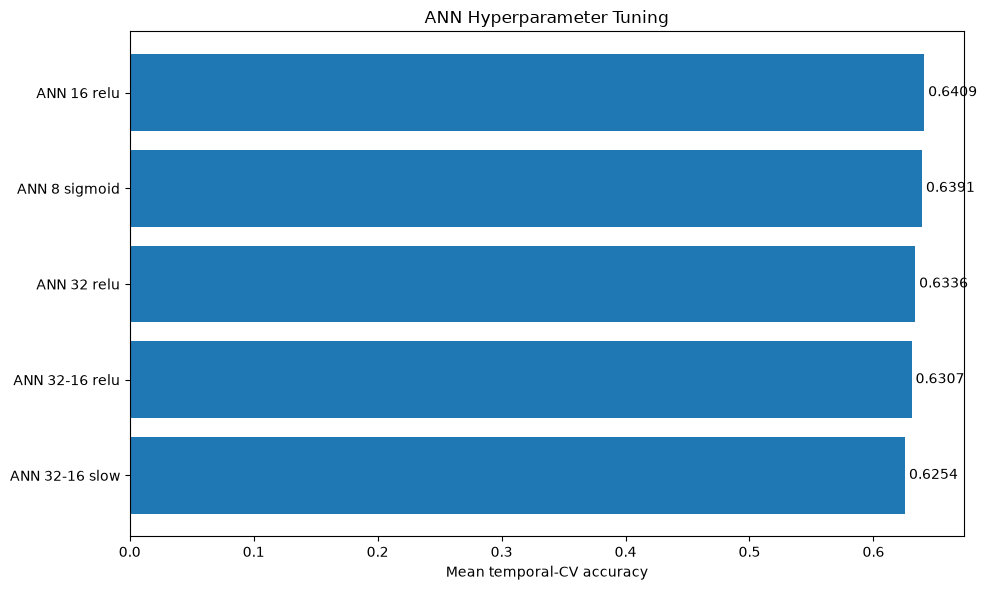

In [20]:
# we create a horizontal bar chart to compare the mean temporal-CV accuracy 
# of the different ANN models tested during hyperparameter tuning
plot_data = ann_cv_tuning_summary.sort_values(
    "MeanAccuracy",
    ascending=True
)


plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlabel("Mean temporal-CV accuracy")
plt.title("ANN Hyperparameter Tuning")

for bar, value in zip(
    bars,
    plot_data["MeanAccuracy"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [21]:
#store the name of the configuartion with best mean temporal-CV accuracy
best_model_name = (ann_cv_tuning_summary.iloc[0]["Model"])
print("Selected ANN from temporal CV:", best_model_name)

Selected ANN from temporal CV: ANN 16 relu


In [22]:
# Retrieve the full parameter set of the selected configuration.
best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"] == best_model_name
)

best_configuration

{'name': 'ANN 16 relu',
 'hidden_layers': [16],
 'activation': 'relu',
 'learning_rate': 0.001,
 'epochs': 50}

We create a fresh model using the selected hyperparameters but without the fold-specific models used during the tuning.

The selected configuration is now retrained from scratch using all training data available up to 2022.

In [23]:
np.random.seed(42)
tf.random.set_seed(42)

best_model = build_model(
    input_features=X_train.shape[1],
    hidden_layers=best_configuration["hidden_layers"],
    hidden_activation= best_configuration["activation"],
    learning_rate=best_configuration["learning_rate"]
)

In [24]:
# train the selected configuration on all training data: 2015-2022
# the 2023 data is kept as an external validation period
best_history = best_model.fit(
    x=X_train,
    y=y_train,
    epochs=best_configuration["epochs"],
    batch_size=128,
    validation_data=(X_validation, y_validation),
    verbose=1
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6323 - loss: 0.6489 - val_accuracy: 0.6272 - val_loss: 0.6287
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6528 - loss: 0.6160 - val_accuracy: 0.6252 - val_loss: 0.6222
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6578 - loss: 0.6108 - val_accuracy: 0.6295 - val_loss: 0.6211
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6606 - loss: 0.6082 - val_accuracy: 0.6287 - val_loss: 0.6208
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6631 - loss: 0.6065 - val_accuracy: 0.6329 - val_loss: 0.6205
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6644 - loss: 0.6052 - val_accuracy: 0.6352 - val_loss: 0.6212
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6650 - loss: 0.6042 - val_accuracy: 0.6352 - val_loss: 0.6214
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6659 - loss: 0.6034 - val_accuracy: 0.

The selected ANN is used to generate probabilities and class predictions for the external validation period. 

We compare the true validation labels agaisnt the predicted validation labels.

The results are reported with standard classification metrics and a confusion matrix.

In [25]:
# probabilities that player 1 wins
best_validation_probabilities = (
    best_model.predict(X_validation, verbose=0).reshape(-1)
) 

# converts probabilities into classes
best_validation_predictions = (
    best_validation_probabilities >= 0.5 
).astype(int) 

# 0.23 -> 0 -> player 2 wins
# 0.81 -> 1 -> player 1 wins

print(
    classification_report(
        y_validation,
        best_validation_predictions,
        target_names=["Player 2 wins","Player 1 wins"],
        zero_division = 0
    ) 
)

               precision    recall  f1-score   support

Player 2 wins       0.65      0.64      0.64      1368
Player 1 wins       0.61      0.62      0.61      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.63      0.63      2607
 weighted avg       0.63      0.63      0.63      2607



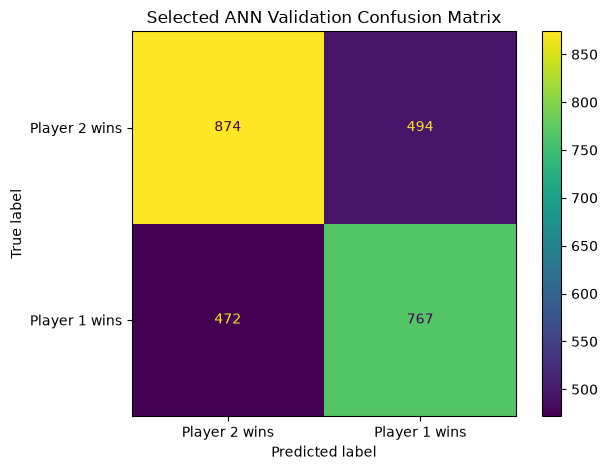

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    display_labels=["Player 2 wins","Player 1 wins"],
    values_format="d"
)

plt.title(
    "Selected ANN Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [27]:
# evaluate the selected ANN on the external 2023 validation set
best_ann_results=evaluate_model(
    y_true=y_validation,
    y_pred=best_validation_predictions,
    y_probability=best_validation_probabilities,
    model_name=best_model_name
)

best_ann_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,ANN 16 relu,0.629459,0.628968,0.608247,0.619048,0.6136,0.690923,0.628562


The learning curves show how accuracy and loss change over the training epochs for the selected ANN, for both the training and validation sets.

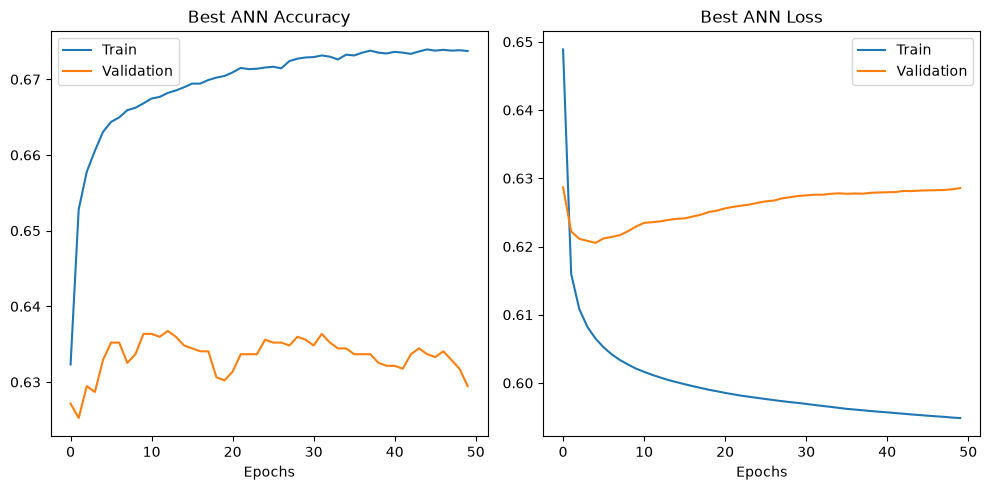

In [28]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(best_history.history["accuracy"], label="Train")
axes[0].plot(best_history.history["val_accuracy"], label="Validation")

axes[0].set_title("Best ANN Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Train")
axes[1].plot(best_history.history["val_loss"], label="Validation")

axes[1].set_title("Best ANN Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# Define output directories and save the experiment results for final analysis
MODEL_SELECTION_RESULTS_DIR = Path("../results/model_selection")

VALIDATION_RESULTS_DIR = Path("../results/validation")

MODELS_DIR = Path("../models")

ann_cv_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR 
    / "ann_cv_fold_results.csv",
    index=False
)

ann_cv_tuning_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR / "ann_cv_tuning_summary.csv",
    index=False
)

best_ann_results.to_csv(
    VALIDATION_RESULTS_DIR / "best_ann_result.csv",
    index=False
)

best_model.save(
    MODELS_DIR / "best_ann_validation.keras"
)

In [30]:
# save the scaler and preprocessing parameters used by the ANN.
import joblib 

joblib.dump(normalizer, MODELS_DIR / "ann_scaler.joblib")

ann_preprocessing = {
    "numeric_medians": numeric_medians,
    "categorical_modes": categorical_modes,
    "one_hot_encoder": one_hot_encoder
}

joblib.dump(ann_preprocessing, MODELS_DIR/"ann_preprocessing.joblib")

['..\\models\\ann_preprocessing.joblib']

In [31]:
# we display final tuning summary 
print("ANN temporal-cv tuning:")

print(ann_cv_tuning_summary)


ANN temporal-cv tuning:
            Model  MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  \
0     ANN 16 relu      0.640926     0.014639              0.641392   
1   ANN 8 sigmoid      0.639128     0.015807              0.640112   
2     ANN 32 relu      0.633604     0.016534              0.634182   
3  ANN 32-16 relu      0.630732     0.016763              0.631038   
4  ANN 32-16 slow      0.625433     0.011917              0.625903   

   MeanF1Score  MeanROC_AUC  MeanLogLoss  
0     0.630924     0.697811     0.627621  
1     0.627414     0.696976     0.632460  
2     0.621622     0.690582     0.635516  
3     0.620959     0.682173     0.649348  
4     0.621516     0.680997     0.650537  


In [32]:
print(
    "Selected ANN:",
    best_model_name
)

print("\nExternal 2023 validation:")
print(best_ann_results)


Selected ANN: ANN 16 relu

External 2023 validation:
         Model  Accuracy  BalancedAccuracy  Precision    Recall      F1  \
0  ANN 16 relu  0.629459          0.628968   0.608247  0.619048  0.6136   

    ROC-AUC   LogLoss  
0  0.690923  0.628562  
